In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train dataset loaded successfully!")
print("Test dataset loaded successfully!")

Train dataset loaded successfully!
Test dataset loaded successfully!


In [5]:
print("Train Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)

Train Dataset Shape: (159571, 8)
Test Dataset Shape: (153164, 2)


In [6]:
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [8]:
train_df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [9]:
print("Duplicate rows:", train_df.duplicated().sum())

Duplicate rows: 0


In [10]:
target_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

train_df[target_columns].sum().sort_values(ascending=False)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64

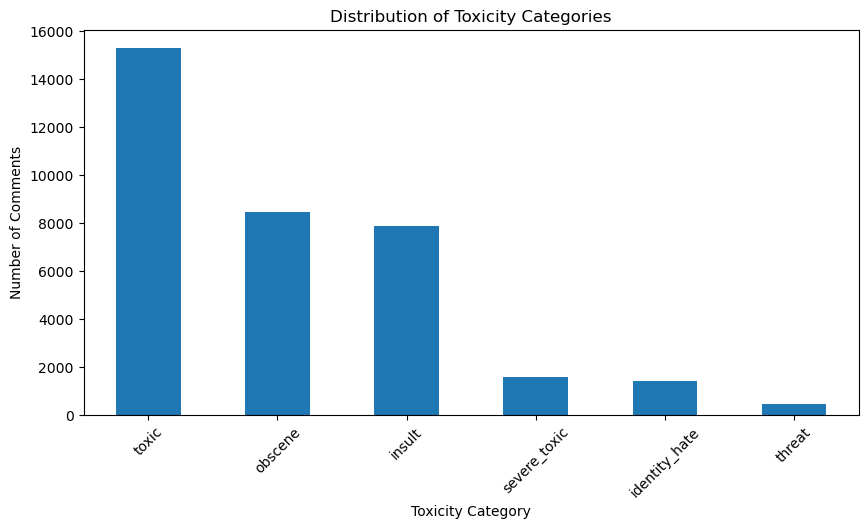

In [11]:
plt.figure(figsize=(10, 5))

train_df[target_columns].sum().sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Distribution of Toxicity Categories")
plt.xlabel("Toxicity Category")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.show()

"The toxicity categories are highly imbalanced. Toxic comments are significantly higher than severe toxic, threat, and identity hate comments. Therefore, appropriate evaluation metrics such as precision, recall, and F1-score should be considered instead of relying only on accuracy."

In [12]:
train_df["comment_length"] = train_df["comment_text"].astype(str).apply(len)

train_df["comment_length"].describe()

count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: comment_length, dtype: float64

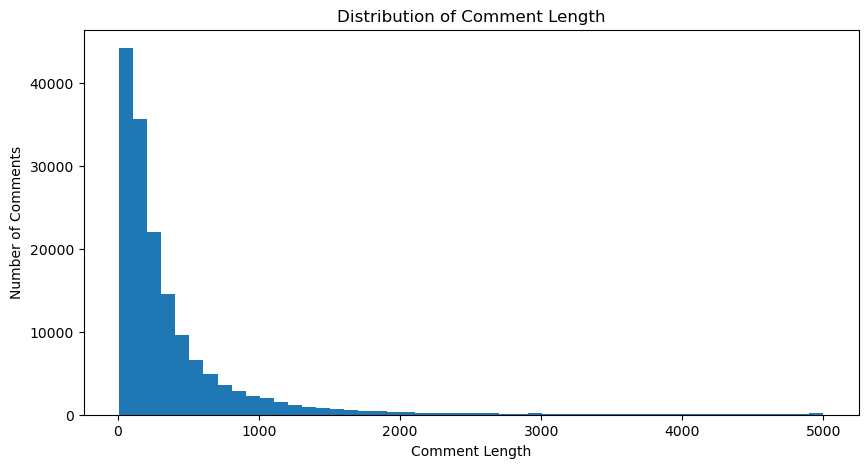

In [13]:
plt.figure(figsize=(10, 5))

plt.hist(train_df["comment_length"], bins=50)

plt.title("Distribution of Comment Length")
plt.xlabel("Comment Length")
plt.ylabel("Number of Comments")

plt.show()

In [14]:
train_df["is_toxic"] = train_df[target_columns].max(axis=1)

print(train_df["is_toxic"].value_counts())

is_toxic
0    143346
1     16225
Name: count, dtype: int64


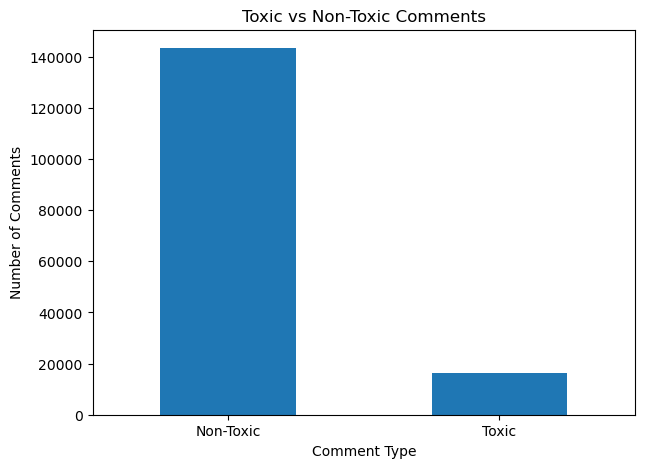

In [15]:
plt.figure(figsize=(7, 5))

train_df["is_toxic"].value_counts().plot(
    kind="bar"
)

plt.title("Toxic vs Non-Toxic Comments")
plt.xlabel("Comment Type")
plt.ylabel("Number of Comments")
plt.xticks(
    ticks=[0, 1],
    labels=["Non-Toxic", "Toxic"],
    rotation=0
)

plt.show()

In [16]:
toxicity_percentage = train_df["is_toxic"].value_counts(normalize=True) * 100

print("Non-Toxic: {:.2f}%".format(toxicity_percentage[0]))
print("Toxic: {:.2f}%".format(toxicity_percentage[1]))

Non-Toxic: 89.83%
Toxic: 10.17%


In [17]:
import re

def clean_text(text):
    """
    Clean the input comment text.
    """
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    
    # Keep only letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [18]:
sample_comments = [
    "YOU are a stupid person!!!",
    "Visit http://example.com NOW!",
    "<b>This is a test comment</b>"
]

for comment in sample_comments:
    print("Original :", comment)
    print("Cleaned  :", clean_text(comment))
    print("-" * 50)

Original : YOU are a stupid person!!!
Cleaned  : you are a stupid person
--------------------------------------------------
Original : Visit http://example.com NOW!
Cleaned  : visit now
--------------------------------------------------
Original : <b>This is a test comment</b>
Cleaned  : this is a test comment
--------------------------------------------------


In [19]:
train_df["clean_comment"] = train_df["comment_text"].apply(clean_text)

train_df[["comment_text", "clean_comment"]].head(10)

,comment_text,clean_comment
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i m se...
2,"Hey man, I'm really not trying to edit war. It...",hey man i m really not trying to edit war it s...
3,"""\nMore\nI can't make any real suggestions on ...",more i can t make any real suggestions on impr...
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...
5,"""\n\nCongratulations from me as well, use the ...",congratulations from me as well use the tools ...
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,cocksucker before you piss around on my work
7,Your vandalism to the Matt Shirvington article...,your vandalism to the matt shirvington article...
8,Sorry if the word 'nonsense' was offensive to ...,sorry if the word nonsense was offensive to yo...
9,alignment on this subject and which are contra...,alignment on this subject and which are contra...


In [20]:
from sklearn.model_selection import train_test_split

X = train_df["clean_comment"]
y = train_df["is_toxic"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 127656
Validation samples: 31915


In [20]:
%pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.6/351.2 MB 9.3 MB/s eta 0:00:38
   ---------------------------------------- 2.9/351.2 MB 7.1 MB/s eta 0:00:49
   ---------------------------------------- 4.2/351.2 MB 7.0 MB/s eta 0:00:50
    --------------------------------------- 5.5/351.2 MB 6.7 MB/s eta 0:00:52
    --------------------------------------- 6.6/351.2 MB 6.5 MB/s eta 0:00:53
    --------------------------------------- 7.9/351.2 MB 6.3 MB/s eta 0:00:55
   - -------------------------------------- 9.4/351.2 MB 6.4 MB/s eta 0:00:54
   - -------------------------------------- 10.2/351.2 MB 6.2 MB/s eta 0:00:56
   - -------------------------------------- 11.3/351.2 MB 6.0 MB/s eta 0:00:57
   - -------------------------------------- 12.3/351.2 MB 6.0 MB/s eta 0:00:57
   - -------------------------------------- 13.4/351.2 MB 5.9 MB/s eta 0:00:58
   - -------------------------------------- 14.9/351.2 MB 6.0 MB/s 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.36.1 which is incompatible.


In [21]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 50000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 144112


In [23]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

print("Original text:")
print(X_train.iloc[0])

print("\nTokenized sequence:")
print(X_train_seq[0])

Original text:
message thanks for the message have fun out there feb utc

Tokenized sequence:
[341, 95, 13, 2, 341, 20, 1083, 81, 44, 2146, 182]


In [24]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("X_train shape:", X_train_pad.shape)
print("X_val shape:", X_val_pad.shape)

X_train shape: (127656, 200)
X_val shape: (31915, 200)


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM
from tensorflow.keras.layers import Dense, Dropout

In [26]:
model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LEN
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.5),

    Dense(32, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy"
    ]
)

print("Model compiled successfully!")

Model compiled successfully!


In [28]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weight_dict)

{0: np.float64(0.5565942307021522), 1: np.float64(4.917411402157165)}


In [29]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=128,
    class_weight=class_weight_dict
)

Epoch 1/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 529s 525ms/step - accuracy: 0.8880 - loss: 0.2838 - val_accuracy: 0.9105 - val_loss: 0.2470
Epoch 2/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 578s 579ms/step - accuracy: 0.9323 - loss: 0.1530 - val_accuracy: 0.9053 - val_loss: 0.2073
Epoch 3/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 541s 541ms/step - accuracy: 0.9497 - loss: 0.1093 - val_accuracy: 0.9339 - val_loss: 0.1539
Epoch 4/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 708s 674ms/step - accuracy: 0.9622 - loss: 0.0810 - val_accuracy: 0.9282 - val_loss: 0.2044
Epoch 5/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 476s 477ms/step - accuracy: 0.9727 - loss: 0.0611 - val_accuracy: 0.9418 - val_loss: 0.1999


Accuracy alone is not enough because our dataset is imbalanced. So now we need to calculate Precision, Recall, F1-score and Confusion Matrix. This is also important for your live evaluation.

In [30]:
y_val_prob = model.predict(X_val_pad)

y_val_pred = (y_val_prob >= 0.5).astype(int).flatten()

print("Predictions generated successfully!")

998/998 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step
Predictions generated successfully!


In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Non-Toxic", "Toxic"]
    )
)

              precision    recall  f1-score   support

   Non-Toxic       0.98      0.95      0.97     28670
       Toxic       0.67      0.85      0.75      3245

    accuracy                           0.94     31915
   macro avg       0.83      0.90      0.86     31915
weighted avg       0.95      0.94      0.94     31915



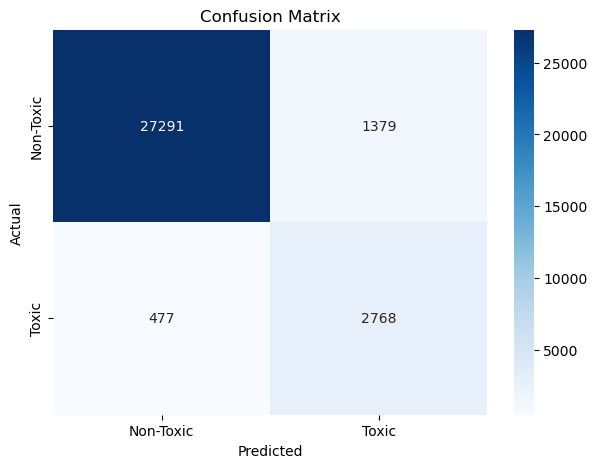

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Toxic", "Toxic"],
    yticklabels=["Non-Toxic", "Toxic"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9418
Precision: 0.6675
Recall   : 0.8530
F1 Score : 0.7489


Precision 66.75% means some comments predicted as toxic are actually non-toxic. So later we can tune the prediction threshold if needed. For now, don't change the model—these are good baseline results.

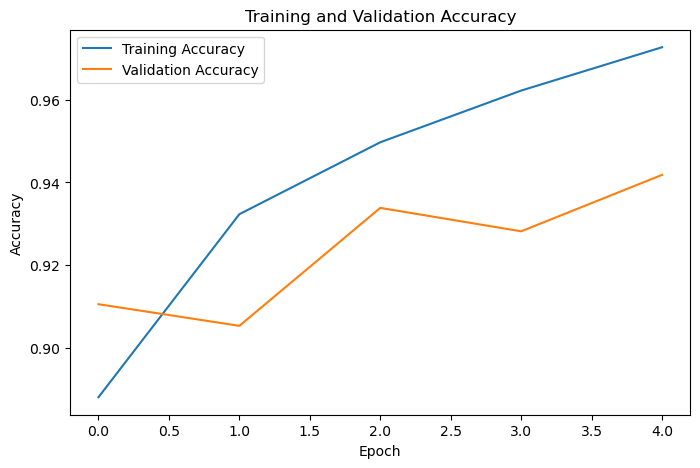

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

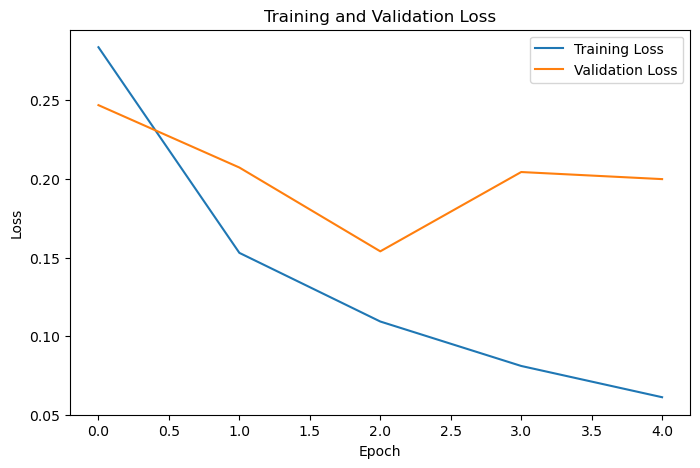

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [36]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/toxicity_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [37]:
import pickle

with open("models/tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [38]:
def predict_toxicity(comment):
    cleaned_comment = clean_text(comment)

    sequence = tokenizer.texts_to_sequences([cleaned_comment])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    probability = model.predict(padded_sequence, verbose=0)[0][0]

    if probability >= 0.5:
        result = "Toxic"
    else:
        result = "Non-Toxic"

    return result, probability

In [39]:
test_comments = [
    "You are a wonderful person.",
    "I really like this article.",
    "You are stupid and useless.",
    "I hate you, get out of here!"
]

for comment in test_comments:
    result, probability = predict_toxicity(comment)

    print("Comment:", comment)
    print("Prediction:", result)
    print("Toxicity Probability:", f"{probability:.2%}")
    print("-" * 60)

Comment: You are a wonderful person.
Prediction: Toxic
Toxicity Probability: 70.60%
------------------------------------------------------------
Comment: I really like this article.
Prediction: Non-Toxic
Toxicity Probability: 27.66%
------------------------------------------------------------
Comment: You are stupid and useless.
Prediction: Toxic
Toxicity Probability: 99.95%
------------------------------------------------------------
Comment: I hate you, get out of here!
Prediction: Toxic
Toxicity Probability: 96.73%
------------------------------------------------------------


In [40]:
test_comments = [
    "You are a wonderful person.",
    "You are a great person.",
    "Thank you for your help.",
    "This is a beautiful day.",
    "I really enjoyed reading this.",
    "Have a nice day.",
    "This is a very useful article.",
    "I completely agree with you.",
    "You did a great job.",
    "What a lovely comment."
]

for comment in test_comments:
    result, probability = predict_toxicity(comment)

    print(f"Comment: {comment}")
    print(f"Prediction: {result}")
    print(f"Toxicity Probability: {probability:.2%}")
    print("-" * 70)

Comment: You are a wonderful person.
Prediction: Toxic
Toxicity Probability: 70.60%
----------------------------------------------------------------------
Comment: You are a great person.
Prediction: Toxic
Toxicity Probability: 78.62%
----------------------------------------------------------------------
Comment: Thank you for your help.
Prediction: Non-Toxic
Toxicity Probability: 0.01%
----------------------------------------------------------------------
Comment: This is a beautiful day.
Prediction: Non-Toxic
Toxicity Probability: 0.14%
----------------------------------------------------------------------
Comment: I really enjoyed reading this.
Prediction: Non-Toxic
Toxicity Probability: 0.17%
----------------------------------------------------------------------
Comment: Have a nice day.
Prediction: Non-Toxic
Toxicity Probability: 1.18%
----------------------------------------------------------------------
Comment: This is a very useful article.
Prediction: Non-Toxic
Toxicity Proba

In [41]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Non-Toxic", "Toxic"],
        digits=4
    )
)

              precision    recall  f1-score   support

   Non-Toxic     0.9828    0.9519    0.9671     28670
       Toxic     0.6675    0.8530    0.7489      3245

    accuracy                         0.9418     31915
   macro avg     0.8251    0.9025    0.8580     31915
weighted avg     0.9508    0.9418    0.9449     31915



In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[27291  1379]
 [  477  2768]]


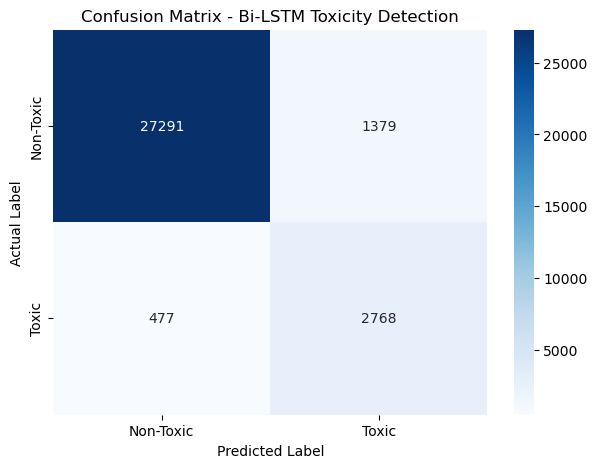

In [43]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Toxic", "Toxic"],
    yticklabels=["Non-Toxic", "Toxic"]
)

plt.title("Confusion Matrix - Bi-LSTM Toxicity Detection")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

“The confusion matrix shows that the model correctly classified 27,291 non-toxic comments and 2,768 toxic comments. It incorrectly classified 1,379 non-toxic comments as toxic and missed 477 toxic comments.”

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:
    predictions = (y_val_prob >= threshold).astype(int).flatten()

    precision = precision_score(y_val, predictions)
    recall = recall_score(y_val, predictions)
    f1 = f1_score(y_val, predictions)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("-" * 40)

Threshold: 0.3
Precision: 0.6248
Recall:    0.8693
F1 Score:  0.7271
----------------------------------------
Threshold: 0.4
Precision: 0.6458
Recall:    0.8598
F1 Score:  0.7376
----------------------------------------
Threshold: 0.5
Precision: 0.6675
Recall:    0.8530
F1 Score:  0.7489
----------------------------------------
Threshold: 0.6
Precision: 0.6943
Recall:    0.8391
F1 Score:  0.7599
----------------------------------------
Threshold: 0.7
Precision: 0.7251
Recall:    0.8240
F1 Score:  0.7714
----------------------------------------
